In [1]:
!pip install  tensorflow-federated

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,roc_curve,confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from tensorflow_federated import learning
from collections import defaultdict


In [5]:
tf.random.set_seed(42)
np.random.seed(42)

# Loan Dataset

In [6]:
data = pd.read_csv('/content/loan-10k.lrn.csv')
final_X_test = pd.read_csv('/content/loan-10k.tes.csv')
final_Y_test = pd.read_csv('/content/loan-10k.sol.ex.csv')

y_train =  pd.DataFrame( data['grade'])
X_train =  pd.DataFrame( data.drop(['grade' , 'ID'], axis=1))
final_X_test =  pd.DataFrame( final_X_test.drop(['ID'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [7]:
le = LabelEncoder()
encoder = OneHotEncoder(handle_unknown='ignore')
#  for the features below we can use Label encoder, they seem ordinal
columns_to_transform = [
    'term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state'
]

for column in columns_to_transform:
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])


y_train["grade"] = le.fit_transform(y_train["grade"])
y_test["grade"] = le.fit_transform(y_test["grade"])
y_train = y_train.to_numpy().flatten()
y_test = y_test.to_numpy().flatten()
# We can drop the columns 'pymnt_plan' and 'addr_state' beacuse they do not have any useful information
X_train = X_train.drop('pymnt_plan', axis=1)
X_train = X_train.drop('hardship_flag', axis=1)

X_test = X_test.drop('pymnt_plan', axis=1)
X_test = X_test.drop('hardship_flag', axis=1)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

encoded = encoder.fit_transform(X_train[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_train = pd.concat([X_train, encoded_df], axis=1)
X_train = X_train.drop('home_ownership', axis=1)


encoded = encoder.transform(X_test[['home_ownership']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['home_ownership']))
X_test = pd.concat([X_test, encoded_df], axis=1)
X_test = X_test.drop('home_ownership', axis=1)

Features = X_train.columns
Features_not_scaled = ['term', 'emp_length', 'verification_status', 'loan_status',
    'purpose', 'initial_list_status', 'application_type',
    'disbursement_method', 'debt_settlement_flag' ,'addr_state' ,"home_ownership_ANY" ,
    "home_ownership_MORTGAGE" ,	"home_ownership_OTHER" ,	"home_ownership_OWN" ,  	"home_ownership_RENT" ]

Features_scaled = [x for x in Features if x not in Features_not_scaled]
scaler = StandardScaler()
X_train[Features_scaled] = scaler.fit_transform(X_train[Features_scaled])
X_test[Features_scaled] = scaler.transform(X_test[Features_scaled])


### Neural Networks

In [8]:
from collections import defaultdict
import numpy as np
import pandas as pd
import tensorflow as tf

def create_federated_data(x, y, num_clients=100, classes_per_client=7,
                         min_samples_per_class=1, largest_client_pct=0.0):
    """
    Creates federated data where:
    - All clients see all classes
    - One client can be larger (optional)

    Args:
        x: Features (DataFrame or array)
        y: Labels (label-encoded array)
        num_clients: Total number of clients
        classes_per_client: Number of classes per client (set to num_classes)
        min_samples_per_class: Minimum samples per class per client
        largest_client_pct: Percentage of total data for largest client (0-1)
                           Set to 0 for balanced distribution
    """
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    # Group indices by class
    for i, label in enumerate(y):
        class_indices[label].append(i)

    total_samples = len(x)
    client_data = []
    all_classes = np.arange(num_classes)

    # Handle largest client if specified
    if largest_client_pct > 0 and num_clients > 1:
        largest_client_size = int(total_samples * largest_client_pct)
        remaining_size = total_samples - largest_client_size

        # Create largest client (with all classes)
        largest_client_indices = []
        for cls in all_classes:
            cls_idxs = class_indices[cls]
            samples = max(min_samples_per_class,
                         int(largest_client_size * (len(cls_idxs)/total_samples)))
            cls_sampled = np.random.choice(cls_idxs, samples, replace=False)
            largest_client_indices.extend(cls_sampled)
            class_indices[cls] = list(set(class_indices[cls]) - set(cls_sampled))

        np.random.shuffle(largest_client_indices)
        largest_client_x = x.iloc[largest_client_indices].values.astype(np.float32)
        largest_client_y = y[largest_client_indices].astype(np.int32)
        largest_client_ds = tf.data.Dataset.from_tensor_slices(
            (largest_client_x, largest_client_y)
        ).shuffle(100).batch(16).repeat(5)
        client_data.append(largest_client_ds)

        # Adjust remaining clients count
        num_remaining_clients = num_clients - 1
        samples_per_remaining_client = remaining_size // num_remaining_clients
    else:
        num_remaining_clients = num_clients
        samples_per_remaining_client = total_samples // num_clients

    # Create remaining clients
    for _ in range(num_remaining_clients):
        client_indices = []
        for cls in all_classes:
            cls_idxs = class_indices[cls]
            samples = max(min_samples_per_class,
                         len(cls_idxs) // num_remaining_clients)
            if len(cls_idxs) == 0:
                continue
            cls_sampled = np.random.choice(cls_idxs, samples, replace=False)
            client_indices.extend(cls_sampled)
            class_indices[cls] = list(set(class_indices[cls]) - set(cls_sampled))

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values.astype(np.float32)
        client_y = y[client_indices].astype(np.int32)
        ds = tf.data.Dataset.from_tensor_slices(
            (client_x, client_y)
        ).shuffle(100).batch(16).repeat(5)
        client_data.append(ds)

    return client_data

In [9]:
def federated_Learning( X_train , y_train,X_test, y_test, number_of_clients, largest_client_pct=0.0):
  federated_train_data = create_federated_data(X_train, y_train ,number_of_clients,largest_client_pct)
  def create_keras_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(7, activation='softmax')
    ])
  def model_fn():
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model(
    keras_model,
    input_spec=federated_train_data[0].element_spec,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

  trainer = learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,
    client_optimizer_fn=learning.optimizers.build_adam(learning_rate=0.01),
    server_optimizer_fn=learning.optimizers.build_sgdm(learning_rate=0.1)
  )
  state = trainer.initialize()
  print(f"Starting federated training... for {number_of_clients} clients ")
  max_accuracy = 0
  counter = 0
  while True:
      state, metrics = trainer.next(state, federated_train_data)
      final_model = trainer.get_model_weights(state).trainable
      keras_model = create_keras_model()
      keras_model.set_weights(final_model)
      keras_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
      loss, acc_test = keras_model.evaluate(X_test, y_test)
      if acc_test > max_accuracy:
        max_accuracy = acc_test
        counter = 0
      else:
        counter += 1
      if counter == 20:
        break


  return max_accuracy

Starting federated training... for 4 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.3207 - accuracy: 0.8650
Starting federated training... for 7 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.3440 - accuracy: 0.8650
Starting federated training... for 10 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.3581 - accuracy: 0.8780
Starting federated training... for 13 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.3715 - accuracy: 0.8500
Starting federated training... for 43 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.4218 - accuracy: 0.8300
Starting federated training... for 73 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.4394 - accuracy: 0.8110
Starting federated training... for 103 clients 
32/32 [==============================] - 0s 2ms/step - loss: 0.5056 - accuracy: 0.8010
Starting federated training... for 4 clients 
32/32 [==========

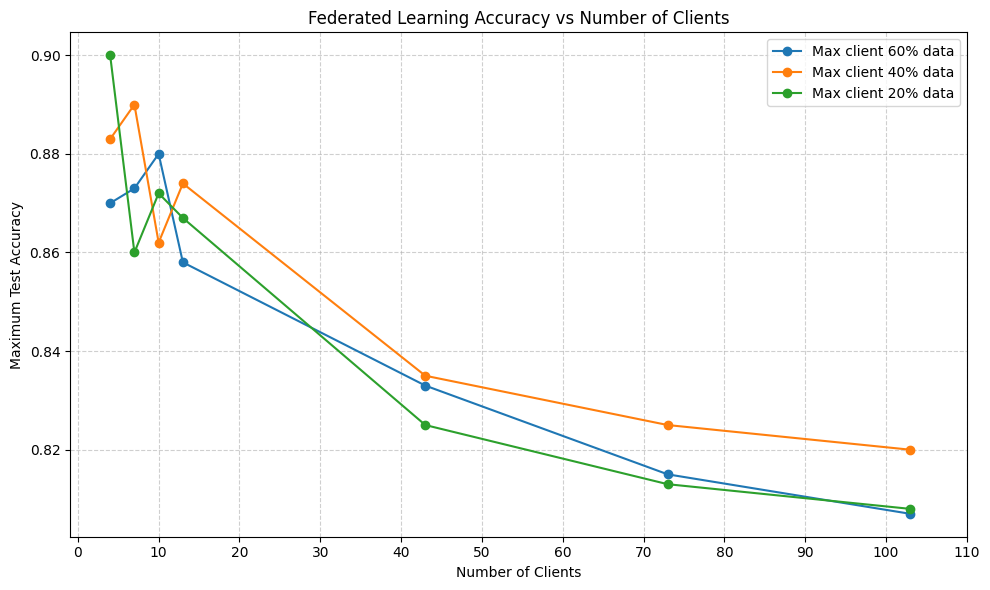

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dictionary to store results for each imbalance level
results = {
    0.6: {'nodes': [], 'max_acc': []},
    0.4: {'nodes': [], 'max_acc': []},
    0.2: {'nodes': [], 'max_acc': []}
}

# Test different imbalance levels
for imbalance_pct in [0.6, 0.4, 0.2]:
    max_acc = []
    nodes = []
    i = 4

    while i <= 110:
        max_accuracy = federated_Learning(X_train, y_train, X_test, y_test, i, imbalance_pct)
        max_acc.append(max_accuracy)
        nodes.append(i)

        if i <= 11:
            i += 3
        else:
            i += 30

    # Store results for this imbalance level
    results[imbalance_pct]['nodes'] = nodes
    results[imbalance_pct]['max_acc'] = max_acc

# Plot all results together
plt.figure(figsize=(10, 6))
for pct, data in results.items():
    plt.plot(data['nodes'], data['max_acc'], 'o-',
             label=f'Max client {pct*100:.0f}% data')

plt.title("Federated Learning Accuracy vs Number of Clients")
plt.xlabel("Number of Clients")
plt.ylabel("Maximum Test Accuracy")
plt.xticks(np.arange(0, 111, 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save results for later use
np.save('fl_results.npy', results)  # Save as binary
plt.savefig('fl_comparison.png', dpi=300)  # Save plot
plt.show()

## Gradient Boosting Decision Tree Federated Learning

In [12]:
def create_federated_data(x, y, num_clients=100, classes_per_client=7,
                         min_samples_per_class=1, largest_client_pct=0.0):
    """
    Creates federated data where:
    - All clients see all classes
    - One client can be larger (optional)

    Args:
        x: Features (DataFrame or array)
        y: Labels (label-encoded array)
        num_clients: Total number of clients
        classes_per_client: Number of classes per client (set to num_classes)
        min_samples_per_class: Minimum samples per class per client
        largest_client_pct: Percentage of total data for largest client (0-1)
                           Set to 0 for balanced distribution
    Returns:
        List of tuples (X_client, y_client) for each client
    """
    num_classes = len(np.unique(y))
    class_indices = defaultdict(list)

    # Group indices by class
    for i, label in enumerate(y):
        class_indices[label].append(i)

    total_samples = len(x)
    client_data = []
    all_classes = np.arange(num_classes)

    # Handle largest client if specified
    if largest_client_pct > 0 and num_clients > 1:
        largest_client_size = int(total_samples * largest_client_pct)
        remaining_size = total_samples - largest_client_size

        # Create largest client (with all classes)
        largest_client_indices = []
        for cls in all_classes:
            cls_idxs = class_indices[cls]
            samples = max(min_samples_per_class,
                         int(largest_client_size * (len(cls_idxs)/total_samples)))
            cls_sampled = np.random.choice(cls_idxs, samples, replace=False)
            largest_client_indices.extend(cls_sampled)
            # Remove used samples from available pool
            class_indices[cls] = list(set(class_indices[cls]) - set(cls_sampled))

        np.random.shuffle(largest_client_indices)
        largest_client_x = x.iloc[largest_client_indices].values
        largest_client_y = y[largest_client_indices].astype(np.int32)
        client_data.append((largest_client_x, largest_client_y))

        # Adjust remaining clients count
        num_remaining_clients = num_clients - 1
    else:
        num_remaining_clients = num_clients

    # Create remaining clients
    for _ in range(num_remaining_clients):
        client_indices = []
        for cls in all_classes:
            cls_idxs = class_indices[cls]
            if len(cls_idxs) == 0:
                continue
            samples = max(min_samples_per_class,
                         len(cls_idxs) // num_remaining_clients)
            cls_sampled = np.random.choice(cls_idxs, samples, replace=False)
            client_indices.extend(cls_sampled)
            # Remove used samples from available pool
            class_indices[cls] = list(set(class_indices[cls]) - set(cls_sampled))

        np.random.shuffle(client_indices)
        client_x = x.iloc[client_indices].values
        client_y = y[client_indices].astype(np.int32)
        client_data.append((client_x, client_y))

    return client_data

Accuracy for 4 clients: 0.976
Accuracy for 7 clients: 0.965
Accuracy for 10 clients: 0.959
Accuracy for 13 clients: 0.959
Accuracy for 16 clients: 0.949
Accuracy for 19 clients: 0.959
Accuracy for 22 clients: 0.952
Accuracy for 25 clients: 0.953
Accuracy for 28 clients: 0.945
Accuracy for 31 clients: 0.962
Accuracy for 34 clients: 0.983
Accuracy for 37 clients: 0.977
Accuracy for 40 clients: 0.972
Accuracy for 43 clients: 0.976
Accuracy for 46 clients: 0.973
Accuracy for 49 clients: 0.972
Accuracy for 52 clients: 0.976
Accuracy for 55 clients: 0.971
Accuracy for 58 clients: 0.974
Accuracy for 61 clients: 0.981
Accuracy for 64 clients: 0.968
Accuracy for 67 clients: 0.982
Accuracy for 70 clients: 0.978
Accuracy for 73 clients: 0.982
Accuracy for 76 clients: 0.972
Accuracy for 79 clients: 0.985
Accuracy for 82 clients: 0.982
Accuracy for 85 clients: 0.97
Accuracy for 88 clients: 0.977
Accuracy for 91 clients: 0.978
Accuracy for 94 clients: 0.984
Accuracy for 97 clients: 0.98
Accuracy for

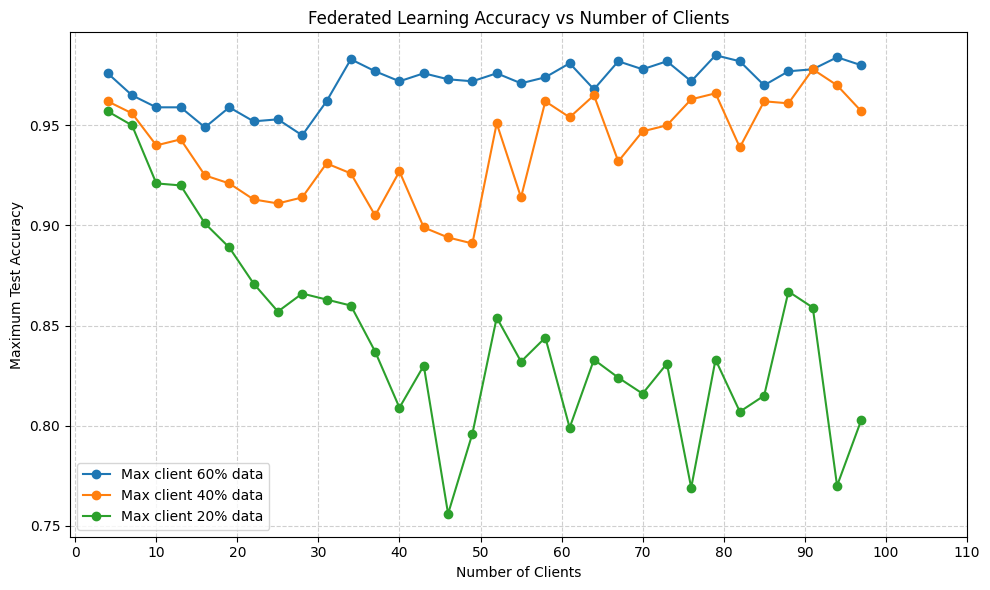

In [13]:
import xgboost as xgb
# Dictionary to store results for each imbalance level
results = {
    0.6: {'nodes': [], 'max_acc': []},
    0.4: {'nodes': [], 'max_acc': []},
    0.2: {'nodes': [], 'max_acc': []}
}

# Test different imbalance levels
for imbalance_pct in [0.6, 0.4, 0.2]:
    nodes = []
    max_acc = []
    for number_of_nodes in range(4, 100,3):
        client_data = create_federated_data(X_train, y_train, number_of_nodes, largest_client_pct =imbalance_pct  )

        booster = None  # Shared model

        for i in range(number_of_nodes):
            X_client, y_client = client_data[i]
            dtrain = xgb.DMatrix(X_client, label=y_client, enable_categorical=True)

            booster = xgb.train(
                params={
                    'objective': 'multi:softprob',
                    'eval_metric': 'mlogloss',
                    'num_class': 7,
                    'verbosity': 0
                },
                dtrain=dtrain,
                num_boost_round=20,
                xgb_model=booster
            )

        dtest = xgb.DMatrix(X_test, enable_categorical=True)
        y_pred_proba = booster.predict(dtest)
        y_pred = np.argmax(y_pred_proba, axis=1)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy for {number_of_nodes} clients: {acc}")
        nodes.append(number_of_nodes)
        max_acc.append(acc)

            # Store results for this imbalance level
    results[imbalance_pct]['nodes'] = nodes
    results[imbalance_pct]['max_acc'] = max_acc

# Plot all results together
plt.figure(figsize=(10, 6))
for pct, data in results.items():
    plt.plot(data['nodes'], data['max_acc'], 'o-',
             label=f'Max client {pct*100:.0f}% data')

plt.title("Federated Learning Accuracy vs Number of Clients")
plt.xlabel("Number of Clients")
plt.ylabel("Maximum Test Accuracy")
plt.xticks(np.arange(0, 111, 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save results for later use
np.save('fl_results.npy', results)  # Save as binary
plt.savefig('fl_comparison.png', dpi=300)  # Save plot
plt.show()